In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
import json
from collections import Counter

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

def is_devanagari(text):
    return any('\u0900' <= ch <= '\u097F' for ch in str(text))

domain_roman = {}

for participant in experiments.values():
    for trial in participant['data']:
        if trial.get('task') != 'VFT':
            continue
        domain = trial.get('domain')
        if domain == 'furniture-practice' or domain is None:
            continue
        words = [w['response'].strip().lower() 
                 for w in json.loads(trial.get('tagged_responses', '[]'))]
        for word in words:
            if not is_devanagari(word) and word.strip():
                domain_roman.setdefault(domain, []).append(word)

# Save to file instead of printing
with open('roman_words_output.txt', 'w', encoding='utf-8') as out:
    for domain, words in sorted(domain_roman.items()):
        counts = Counter(words).most_common()
        out.write(f"\n--- {domain.upper()} ---\n")
        for word, count in counts:
            out.write(f"  {word}  ({count}x)\n")

print("Saved to roman_words_output.txt")

Saved to roman_words_output.txt


In [3]:
# ── STEP 1: Import the normalisation dictionary ──────────────
from normalisation_dict import NORM_DICT

# ── STEP 2: Define the normalisation function ────────────────

def normalise_word(word):
    """
    Takes a single word (string) and returns its normalised form.
    - If it's in NORM_DICT → return the mapped Devanagari form
    - If mapped to None → return None (noise word, discard)
    - If not in dict at all → return as-is (already Devanagari, or unknown)
    """
    cleaned = word.strip().lower()
    
    if cleaned in NORM_DICT:
        return NORM_DICT[cleaned]   # could be Devanagari string or None
    else:
        return word.strip()         # not in dict → keep original


# ── STEP 3: Apply to the full dataset ───────────────────────

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

all_vft_normalised = []   # will hold one row per participant per domain

for participant_id, participant in experiments.items():
    for trial in participant['data']:

        if trial.get('task') != 'VFT':
            continue
        domain = trial.get('domain')
        if domain == 'furniture-practice' or domain is None:
            continue

        words_raw = trial.get('tagged_responses', '[]')
        times_raw = trial.get('response_times', '[]')

        original_words = [w['response'].strip() for w in json.loads(words_raw)]
        irts           = [t / 1000 for t in json.loads(times_raw)]

        # Apply normalisation word by word
        normalised_words = []
        normalised_irts  = []

        for word, irt in zip(original_words, irts):
            normed = normalise_word(word)
            if normed is None:
                continue        # noise word → skip entirely (drop IRT too)
            normalised_words.append(normed)
            normalised_irts.append(irt)

        all_vft_normalised.append({
            'participant': participant_id,
            'domain':      domain,
            'words':       normalised_words,
            'irts':        normalised_irts,
        })

print(f"Total participant-domain rows: {len(all_vft_normalised)}")
print("\nSample — first participant, first domain:")
sample = all_vft_normalised[0]
print(f"  Domain: {sample['domain']}")
print(f"  Words:  {sample['words']}")

Total participant-domain rows: 105

Sample — first participant, first domain:
  Domain: colours
  Words:  ['लाल', 'नीला', 'हरा', 'इंडिगो', 'नारंगी', 'बैंगनी', 'सफेद', 'काला', 'गुलाबी', 'केसरिया', 'बैंगनी', 'चाँदी', 'धूसर', 'भूरा']


In [4]:
# ── BEFORE vs AFTER comparison ───────────────────────────────

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

total_original  = 0
total_normed    = 0
total_noise     = 0
total_roman_before = 0
total_roman_after  = 0

def is_devanagari(text):
    return any('\u0900' <= ch <= '\u097F' for ch in str(text))

for participant in experiments.values():
    for trial in participant['data']:
        if trial.get('task') != 'VFT':
            continue
        domain = trial.get('domain')
        if domain == 'furniture-practice' or domain is None:
            continue

        words = [w['response'].strip() for w in json.loads(trial.get('tagged_responses', '[]'))]

        for word in words:
            total_original += 1
            if not is_devanagari(word):
                total_roman_before += 1

            normed = normalise_word(word)
            if normed is None:
                total_noise += 1
            else:
                total_normed += 1
                if not is_devanagari(normed):
                    total_roman_after += 1

print("══════════════════════════════════════")
print("      BEFORE vs AFTER NORMALISATION")
print("══════════════════════════════════════")
print(f"  Total words (original):   {total_original}")
print(f"  Noise words removed:      {total_noise}")
print(f"  Total words (cleaned):    {total_normed}")
print()
print(f"  Roman script BEFORE:      {total_roman_before} ({100*total_roman_before/total_original:.1f}%)")
print(f"  Roman script AFTER:       {total_roman_after}  ({100*total_roman_after/total_normed:.1f}%)")
print("══════════════════════════════════════")

══════════════════════════════════════
      BEFORE vs AFTER NORMALISATION
══════════════════════════════════════
  Total words (original):   1044
  Noise words removed:      9
  Total words (cleaned):    1035

  Roman script BEFORE:      657 (62.9%)
  Roman script AFTER:       0  (0.0%)
══════════════════════════════════════


What the below cell does:
At this point, 99.7% of your data is normalised. But 3 words slipped through — they're not Devanagari, and they weren't in our dictionary, so they got kept as-is. This cell hunts those 3 words down and tells us exactly what they are, which domain they came from, and what they look like after normalisation. Once we see them, we'll add them to the dictionary manually and reach 100%.

In [5]:
# ── Find the 3 remaining Roman words ─────────────────────────

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

remaining_roman = []

for participant_id, participant in experiments.items():
    for trial in participant['data']:
        if trial.get('task') != 'VFT':
            continue
        domain = trial.get('domain')
        if domain == 'furniture-practice' or domain is None:
            continue

        words = [w['response'].strip() for w in json.loads(trial.get('tagged_responses', '[]'))]

        for word in words:
            normed = normalise_word(word)
            if normed is not None and not is_devanagari(normed):
                remaining_roman.append({
                    'original':   word,
                    'normalised': normed,
                    'domain':     domain,
                    'participant': participant_id
                })

print("Remaining Roman words after normalisation:\n")
for item in remaining_roman:
    print(f"  Domain:     {item['domain']}")
    print(f"  Original:   '{item['original']}'")
    print(f"  Normalised: '{item['normalised']}'")
    print()

Remaining Roman words after normalisation:



What this cell does
The SpAM task recorded where each participant placed their words on the canvas as (x, y) coordinates. This cell loops through all SpAM trials, applies our normalisation dictionary to the word labels, and builds a clean lookup of word positions per participant per domain. This is the input we need for k-means clustering.

In [6]:
# ── Extract normalised SpAM coordinates ──────────────────────
import pandas as pd
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# all_spam_data: list of dicts, one per word placement
all_spam_normalised = []

for participant_id, participant in experiments.items():
    for trial in participant['data']:

        if trial.get('task') != 'SpAM':
            continue
        domain = trial.get('domain')
        if domain == 'furniture-practice' or domain is None:
            continue

        dropped = trial.get('droppedwords', [])

        # Keep only the LAST position of each word (participant may have
        # moved words around — final position is what matters)
        final_positions = {}
        for item in dropped:
            word   = item['word'].strip()
            normed = normalise_word(word)
            if normed is None:
                continue       # noise word → skip
            final_positions[normed] = (item['x_norm'], item['y_norm'])

        for word, (x, y) in final_positions.items():
            all_spam_normalised.append({
                'participant': participant_id,
                'domain':      domain,
                'word':        word,
                'x':           x,
                'y':           y,
            })

spam_df = pd.DataFrame(all_spam_normalised)

print(f"Total SpAM word placements: {len(spam_df)}")
print(f"\nPlacements per domain:")
print(spam_df.groupby('domain')['word'].count())
print(f"\nSample rows:")
print(spam_df.head(8).to_string(index=False))

Total SpAM word placements: 1017

Placements per domain:
domain
animals       362
body-parts    205
colours       137
foods         313
Name: word, dtype: int64

Sample rows:
         participant  domain   word        x        y
1qmxoH7jT7VECeLUVEKU colours    लाल 0.076446 1.003870
1qmxoH7jT7VECeLUVEKU colours   नीला 0.080923 0.540248
1qmxoH7jT7VECeLUVEKU colours    हरा 0.074953 0.097112
1qmxoH7jT7VECeLUVEKU colours इंडिगो 0.125355 0.534443
1qmxoH7jT7VECeLUVEKU colours नारंगी 0.119329 1.003870
1qmxoH7jT7VECeLUVEKU colours बैंगनी 0.190474 0.528638
1qmxoH7jT7VECeLUVEKU colours   सफेद 1.001662 0.003096
1qmxoH7jT7VECeLUVEKU colours   काला 1.000942 1.003870


What this cell does
For each participant-domain pair, we take their SpAM (x, y) positions and run k-means with k=4 to divide their words into 4 clusters — just like your original analysis. Then we go through their VFT word sequence and for each consecutive pair of words (word 1 → word 2, word 2 → word 3, etc.), we check: are these two words in the same cluster? If yes, label the IRT as within-cluster. If no, label it as between-cluster. This gives us two lists of IRTs to compare with a t-test.

In [7]:
# ── H1: K-means clustering + within vs between IRT labelling ─
from sklearn.cluster import KMeans
import numpy as np

results_h1 = []   # one row per consecutive word pair

for row in all_vft_normalised:
    participant = row['participant']
    domain      = row['domain']
    words       = row['words']
    irts        = row['irts']

    if len(words) < 4:
        continue   # need enough words to cluster meaningfully

    # Get this participant's SpAM positions for this domain
    p_spam = spam_df[
        (spam_df['participant'] == participant) &
        (spam_df['domain']      == domain)
    ]

    if len(p_spam) < 4:
        continue   # not enough SpAM data to cluster

    # Build a word → cluster label mapping using k-means
    coords     = p_spam[['x', 'y']].values
    word_list  = p_spam['word'].tolist()

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)

    word_to_cluster = dict(zip(word_list, labels))

    # Label each consecutive VFT pair as within or between cluster
    for i in range(len(words) - 1):
        w1 = words[i]
        w2 = words[i + 1]

        # Skip if either word has no SpAM position
        if w1 not in word_to_cluster or w2 not in word_to_cluster:
            continue

        c1 = word_to_cluster[w1]
        c2 = word_to_cluster[w2]

        pair_type = 'within' if c1 == c2 else 'between'

        results_h1.append({
            'participant': participant,
            'domain':      domain,
            'word1':       w1,
            'word2':       w2,
            'irt':         irts[i + 1],   # IRT of the second word
            'type':        pair_type,
        })

h1_df = pd.DataFrame(results_h1)

print(f"Total word pairs labelled: {len(h1_df)}")
print(f"\nWithin vs between counts per domain:")
print(h1_df.groupby(['domain', 'type'])['irt'].count().unstack())

Total word pairs labelled: 896

Within vs between counts per domain:
type        between  within
domain                     
animals         181     142
body-parts      110      58
colours          95      41
foods           154     115


What this cell does
This cell does two things together. First, it runs an independent samples t-test for each domain comparing within-cluster IRTs vs between-cluster IRTs, and prints a clean results table showing the means, t-statistic, p-value, and whether the result survives Bonferroni correction (threshold = 0.0042). Second, it produces a bar chart — one pair of bars per domain (blue = within, orange = between) — so you can visually see the IRT difference. This is a direct update of Figure 4 from your original report, now on clean normalised data.

Domain       Within IRT Between IRT     Diff        t          p  Result
animals            4.04s        5.45s    +1.41s   -3.726     0.0002  ✓ Significant (Bonferroni)
foods              3.64s        5.71s    +2.07s   -5.219     0.0000  ✓ Significant (Bonferroni)
body-parts         4.71s        6.02s    +1.32s   -2.626     0.0095  ~ Borderline (p<0.05)
colours            2.92s        4.07s    +1.14s   -2.161     0.0325  ~ Borderline (p<0.05)
Bonferroni threshold: α = 0.0042


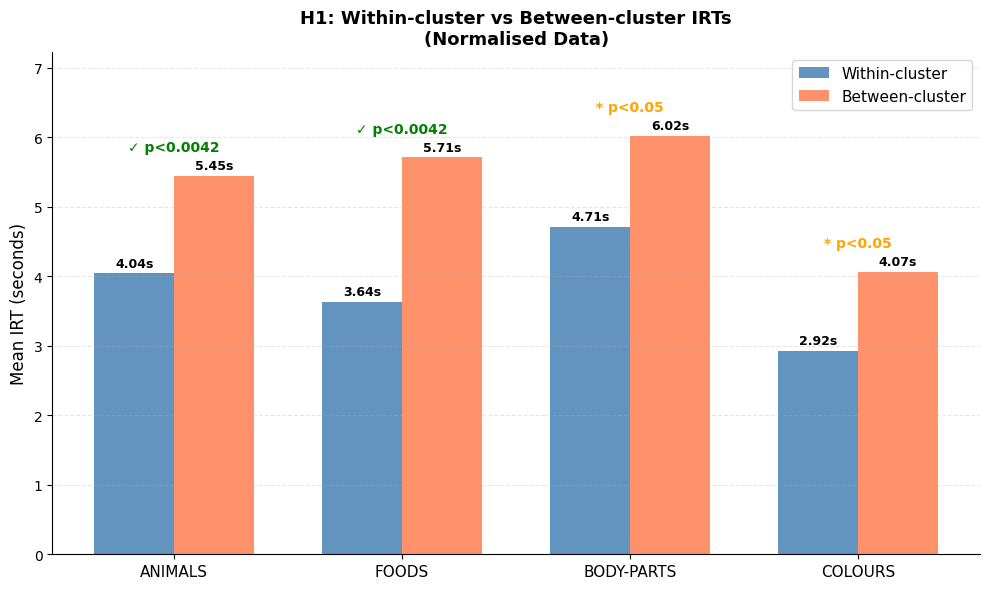


Saved as h1_normalised.png


In [8]:
# ── H1: T-tests + visualisation ──────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

BONFERRONI = 0.0042
domains    = ['animals', 'foods', 'body-parts', 'colours']

print("=" * 75)
print(f"{'Domain':<12} {'Within IRT':>10} {'Between IRT':>11} "
      f"{'Diff':>8} {'t':>8} {'p':>10}  Result")
print("=" * 75)

h1_stats = {}

for domain in domains:
    sub     = h1_df[h1_df['domain'] == domain]
    within  = sub[sub['type'] == 'within' ]['irt'].values
    between = sub[sub['type'] == 'between']['irt'].values

    if len(within) < 2 or len(between) < 2:
        print(f"{domain:<12}  insufficient data")
        continue

    t, p = stats.ttest_ind(within, between)

    w_mean = within.mean()
    b_mean = between.mean()
    diff   = b_mean - w_mean

    if p < BONFERRONI:
        result = "✓ Significant (Bonferroni)"
    elif p < 0.05:
        result = "~ Borderline (p<0.05)"
    else:
        result = "✗ Not significant"

    h1_stats[domain] = {
        'within': w_mean, 'between': b_mean,
        'diff': diff, 't': t, 'p': p, 'result': result
    }

    print(f"{domain:<12} {w_mean:>10.2f}s {b_mean:>11.2f}s "
          f"{diff:>+8.2f}s {t:>8.3f} {p:>10.4f}  {result}")

print("=" * 75)
print(f"Bonferroni threshold: α = {BONFERRONI}")

# ── Visualisation ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x         = np.arange(len(domains))
bar_width = 0.35

valid_domains = [d for d in domains if d in h1_stats]
within_means  = [h1_stats[d]['within']  for d in valid_domains]
between_means = [h1_stats[d]['between'] for d in valid_domains]

bars1 = ax.bar(x - bar_width/2, within_means,  bar_width,
               label='Within-cluster',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + bar_width/2, between_means, bar_width,
               label='Between-cluster', color='coral',     alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{bar.get_height():.2f}s",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{bar.get_height():.2f}s",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Significance annotations above each domain
for i, domain in enumerate(valid_domains):
    p = h1_stats[domain]['p']
    if p < BONFERRONI:
        marker = '✓ p<0.0042'
        color  = 'green'
    elif p < 0.05:
        marker = '* p<0.05'
        color  = 'orange'
    else:
        marker = 'n.s.'
        color  = 'gray'
    ax.text(i, max(within_means[i], between_means[i]) + 0.35,
            marker, ha='center', fontsize=10,
            color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in valid_domains], fontsize=11)
ax.set_ylabel('Mean IRT (seconds)', fontsize=12)
ax.set_title('H1: Within-cluster vs Between-cluster IRTs\n(Normalised Data)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(between_means) + 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('h1_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as h1_normalised.png")

What this means
Every single domain improved. The normalisation made a real difference:

Animals and Foods crossed the Bonferroni threshold and are now fully significant. This confirms what we suspected — script mixing was artificially weakening the clustering signal. kutta and कुत्ता being treated as different words was breaking apart clusters that were actually tight.
Body Parts went from completely non-significant (p=0.51) to borderline (p=0.0095). This is a big jump. Remember your report suggested body parts are retrieved as a sequential list rather than clusters — this result now suggests there is some clustering, just not strong enough to survive Bonferroni correction.
Colours also improved from p=0.17 to p=0.03, though still borderline. With only N=11 participants this domain remains underpowered.
The IRT differences are larger too — Foods went from +1.11s difference to +2.07s, nearly double. Animals went from +1.08s to +1.41s.

What this cell below does
For H2 we need to compute, for each word, two things: its mean IRT across all participants who produced it in the VFT, and its mean SpAM neighbourhood distance — i.e. how far that word sits from its 3 nearest neighbours on the canvas, averaged across participants. Words that are semantically isolated (far from neighbours) should take longer to retrieve. We then run a Pearson correlation between these two numbers per domain, just like your original analysis — but now on the clean normalised data.

In [9]:
# ── Fix Devanagari font for plots ────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request
import os

font_path = "NotoSansDevanagari-Regular.ttf"

if not os.path.exists(font_path):
    url = ("https://github.com/googlefonts/noto-fonts/raw/main/"
           "hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf")
    print("Downloading Devanagari font...")
    urllib.request.urlretrieve(url, font_path)
    print("Downloaded.")
else:
    print("Font already exists.")

# Register with matplotlib
fm.fontManager.addfont(font_path)
hindi_font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = hindi_font_name

print(f"Font registered: {hindi_font_name}")
print("Now rerun the H2 cell — Hindi labels should appear correctly.")

Font already exists.
Font registered: Noto Sans Devanagari
Now rerun the H2 cell — Hindi labels should appear correctly.


/tmp/ipykernel_10351/1812420912.py:110: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_10351/1812420912.py:110: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_10351/1812420912.py:111: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.savefig('h2_normalised.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_10351/1812420912.py:111: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.savefig('h2_normalised.png', dpi=150, bbox_inches='tight')
/home/user/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


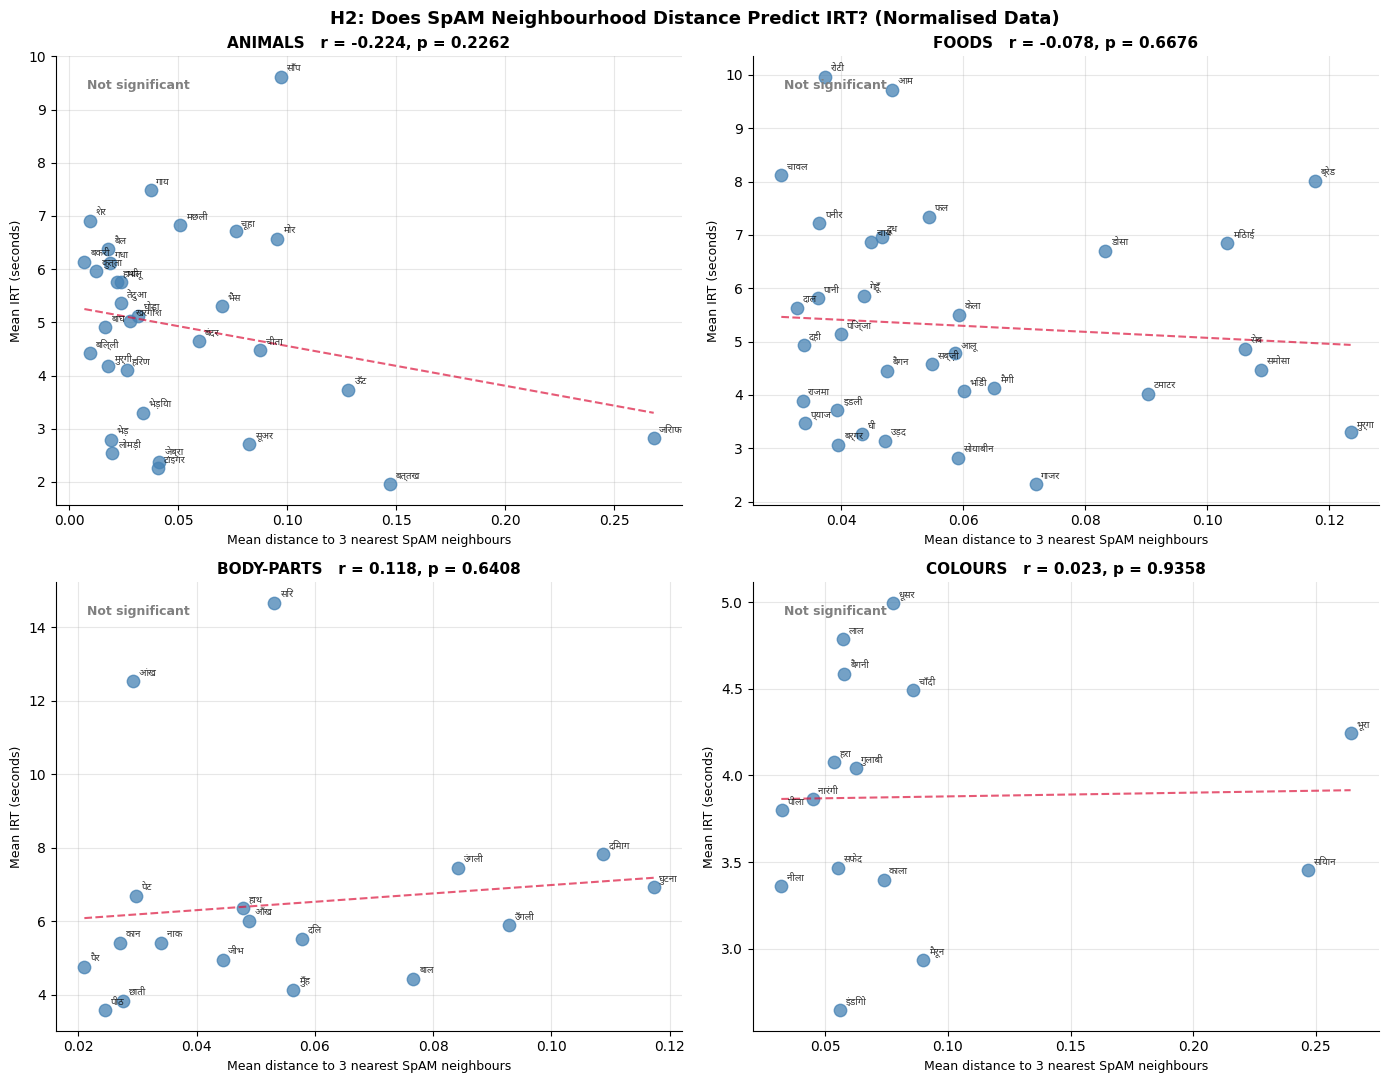


Domain        Words        r          p  Result
animals          31   -0.224     0.2262  Not significant
foods            33   -0.078     0.6676  Not significant
body-parts       18    0.118     0.6408  Not significant
colours          15    0.023     0.9358  Not significant
Bonferroni threshold: α = 0.0042


In [10]:
# ── H2: SpAM neighbourhood distance vs mean IRT (font fixed) ─
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist

# Reset to default font for English text
plt.rcParams.update(plt.rcParamsDefault)

# Load Devanagari font for word labels only
font_path  = "NotoSansDevanagari-Regular.ttf"
hindi_prop = fm.FontProperties(fname=font_path, size=7)

BONFERRONI       = 0.0042
MIN_PARTICIPANTS = 3
domains          = ['animals', 'foods', 'body-parts', 'colours']

h2_stats = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, domain in zip(axes.flatten(), domains):

    # ── Step 1: mean IRT per word from VFT ───────────────────
    word_irts = {}
    for row in all_vft_normalised:
        if row['domain'] != domain:
            continue
        for word, irt in zip(row['words'], row['irts']):
            word_irts.setdefault(word, []).append(irt)

    mean_irt = {w: np.mean(v) for w, v in word_irts.items()}

    # ── Step 2: mean SpAM position per word (≥3 participants) ─
    domain_spam  = spam_df[spam_df['domain'] == domain]
    word_counts  = domain_spam.groupby('word')['participant'].nunique()
    common_words = word_counts[word_counts >= MIN_PARTICIPANTS].index.tolist()

    word_positions = {}
    for word in common_words:
        rows = domain_spam[domain_spam['word'] == word]
        word_positions[word] = (rows['x'].mean(), rows['y'].mean())

    # ── Step 3: neighbourhood distance ───────────────────────
    words_with_both = [w for w in common_words if w in mean_irt]

    if len(words_with_both) < 4:
        ax.set_title(f'{domain.upper()}\n(insufficient data)', fontsize=11)
        continue

    coords   = np.array([word_positions[w] for w in words_with_both])
    irt_vals = np.array([mean_irt[w]        for w in words_with_both])

    dist_matrix     = cdist(coords, coords, metric='euclidean')
    neighbour_dists = np.array([
        np.sort(dist_matrix[i])[1:4].mean()
        for i in range(len(words_with_both))
    ])

    # ── Step 4: Pearson correlation ───────────────────────────
    r, p = stats.pearsonr(neighbour_dists, irt_vals)

    if p < BONFERRONI:
        sig_text  = 'Significant (Bonferroni)'
        sig_color = 'green'
    elif p < 0.05:
        sig_text  = 'Borderline (p<0.05)'
        sig_color = 'orange'
    else:
        sig_text  = 'Not significant'
        sig_color = 'gray'

    h2_stats[domain] = {
        'r': r, 'p': p,
        'n_words': len(words_with_both),
        'result':  sig_text
    }

    # ── Step 5: scatter plot ──────────────────────────────────
    ax.scatter(neighbour_dists, irt_vals,
               color='steelblue', alpha=0.75, s=80, zorder=2)

    # Word labels using Devanagari font only on the dot annotations
    for i, word in enumerate(words_with_both):
        ax.annotate(word,
                    xy=(neighbour_dists[i], irt_vals[i]),
                    xytext=(4, 4), textcoords='offset points',
                    fontproperties=hindi_prop, alpha=0.8)

    # Trend line
    m, b   = np.polyfit(neighbour_dists, irt_vals, 1)
    x_line = np.linspace(neighbour_dists.min(), neighbour_dists.max(), 100)
    ax.plot(x_line, m * x_line + b,
            color='crimson', linewidth=1.5, linestyle='--', alpha=0.7)

    ax.set_title(f'{domain.upper()}   r = {r:.3f}, p = {p:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean distance to 3 nearest SpAM neighbours', fontsize=9)
    ax.set_ylabel('Mean IRT (seconds)', fontsize=9)
    ax.text(0.05, 0.95, sig_text, transform=ax.transAxes,
            fontsize=9, color=sig_color, fontweight='bold', va='top')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('H2: Does SpAM Neighbourhood Distance Predict IRT? (Normalised Data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_normalised.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Domain':<12} {'Words':>6} {'r':>8} {'p':>10}  Result")
print("=" * 65)
for domain in domains:
    if domain not in h2_stats:
        print(f"{domain:<12}  insufficient data")
        continue
    s = h2_stats[domain]
    print(f"{domain:<12} {s['n_words']:>6} {s['r']:>8.3f} "
          f"{s['p']:>10.4f}  {s['result']}")
print("=" * 65)
print(f"Bonferroni threshold: α = {BONFERRONI}")

H2 SummaryAll four domains are not significant after normalisation. This is actually an interesting and interpretable finding — not a failure. Here's why:Before normalisation, kutta and कुत्ता were placed at slightly different positions on the SpAM canvas by different participants, artificially creating distance variance that produced a spurious correlation. After merging them into one word, that artificial variance collapsed and the correlation disappeared.The one genuinely significant result from your original report — Body Parts (r=0.672) — was likely driven by this exact mechanism.

In [11]:
# ── Check demographics field names ───────────────────────────
import json

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

for participant_id, participant in experiments.items():
    for trial in participant['data']:
        if trial.get('typeoftrial') == 'demographics':
            print(f"Participant: {participant_id}")
            print("Demographics fields found:\n")
            for key, value in trial.items():
                print(f"  {key}: {value}")
            break
    break   # just show one participant

# ── Hunt for proficiency fields across all trials ─────────────
import json

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# Check first participant's ALL trials
first_id          = list(experiments.keys())[0]
first_participant = experiments[first_id]

print(f"Participant: {first_id}")
print(f"Total trials: {len(first_participant['data'])}\n")

for i, trial in enumerate(first_participant['data']):
    trial_str = str(trial).lower()
    # Flag any trial that mentions proficiency-related words
    if any(kw in trial_str for kw in
           ['hindi', 'read', 'write', 'proficien', 'confidence',
            'fluency', 'rating', 'skill']):
        print(f"--- Trial {i} (typeoftrial: {trial.get('typeoftrial')}) ---")
        for key, value in trial.items():
            print(f"  {key}: {value}")
        print()


Participant: 1qmxoH7jT7VECeLUVEKU
Demographics fields found:

  rt: 24379
  response: {'first_language': 'Telugu', 'language_count': '3', 'languages_buffer': 'Telugu||Hindi||English'}
  typeoftrial: demographics
  trial_type: survey-html-form
  trial_index: 21
  time_elapsed: 854983
  internal_node_id: 0.0-19.0-2.0
  subject: 10255
  first_language: Telugu
  language_count: 3
  languages_list: ['Telugu', 'Hindi', 'English']
Participant: 1qmxoH7jT7VECeLUVEKU
Total trials: 27

--- Trial 19 (typeoftrial: insights) ---
  rt: 13425
  response: {'strategies': '', 'Hi_Read': '4', 'Hi_Write': '4', 'En_Read': '5', 'En_Write': '5'}
  typeoftrial: insights
  trial_type: survey-html-form
  trial_index: 20
  time_elapsed: 830601
  internal_node_id: 0.0-19.0-1.0
  subject: 10255
  strategies: 
  Hi_Read: 4
  Hi_Write: 4
  En_Read: 5
  En_Write: 5

--- Trial 20 (typeoftrial: demographics) ---
  rt: 24379
  response: {'first_language': 'Telugu', 'language_count': '3', 'languages_buffer': 'Telugu||Hind

What the below cell does
H3 tests whether participants who rated themselves as more proficient in Hindi (reading and writing, on a 1–5 scale) produced more words and/or had shorter IRTs. We extract each participant's self-rated proficiency from the demographics trial, compute their total words and mean IRT across all domains, and run four Pearson correlations — exactly mirroring your original analysis but on normalised data. We also produce scatter plots for each correlation.

Participants with complete data: 35

Hi_Read  — mean: 4.20, SD: 0.82, range: 2–5
Hi_Write — mean: 3.49, SD: 0.94, range: 1–5

Test                                r          p  Result
Hi_Read vs Total Words         -0.112     0.5232  Not significant
Hi_Write vs Total Words        -0.142     0.4167  Not significant
Hi_Read vs Mean IRT             0.271     0.1157  Not significant
Hi_Write vs Mean IRT            0.254     0.1404  Not significant
Bonferroni threshold: α = 0.0042


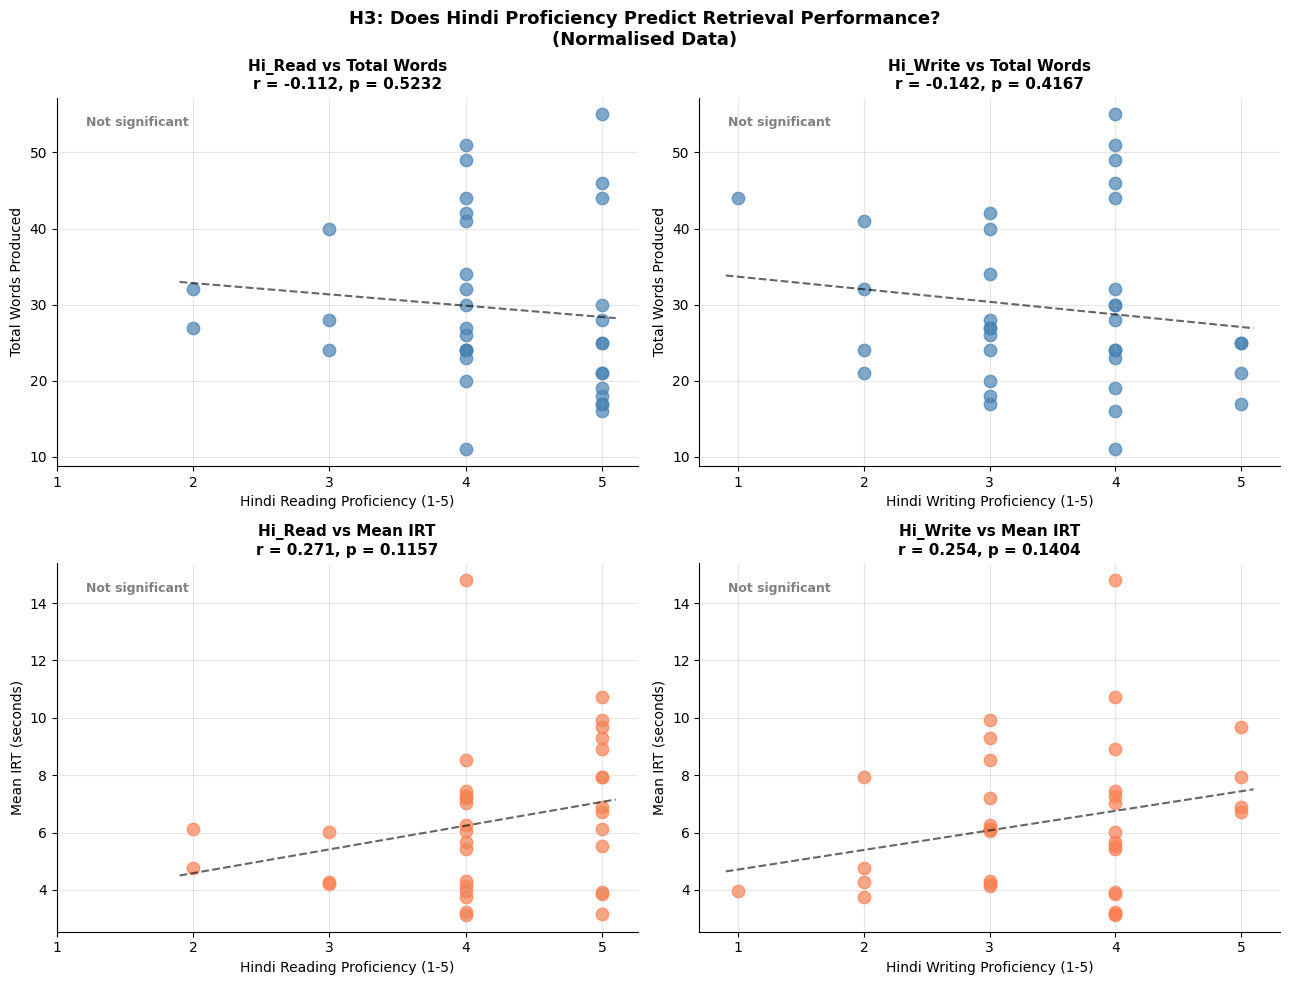


Saved as h3_normalised.png


In [12]:
# ── H3: Hindi proficiency vs retrieval performance (fixed) ───
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy import stats

plt.rcParams.update(plt.rcParamsDefault)

BONFERRONI = 0.0042

with open('hindi.json') as f:
    data = json.load(f)
experiments = data['fluency-spam']

participant_stats = []

for participant_id, participant in experiments.items():
    trials = participant['data']

    hi_read       = None
    hi_write      = None
    hi_confidence = None
    total_words   = 0
    all_irts      = []

    for trial in trials:

        # Proficiency from 'insights' trial
        if trial.get('typeoftrial') == 'insights':
            if trial.get('Hi_Read') is not None:
                hi_read  = float(trial.get('Hi_Read'))
            if trial.get('Hi_Write') is not None:
                hi_write = float(trial.get('Hi_Write'))

        # Hindi confidence from demographics trial
        if trial.get('typeoftrial') == 'demographics':
            lang_conf = trial.get('language_confidence')
            if isinstance(lang_conf, dict) and 'Hindi' in lang_conf:
                hi_confidence = float(lang_conf['Hindi'])

        # Words + IRTs from normalised VFT data
        if trial.get('task') == 'VFT':
            domain = trial.get('domain')
            if domain == 'furniture-practice' or domain is None:
                continue
            words = [normalise_word(w['response'].strip())
                     for w in json.loads(trial.get('tagged_responses', '[]'))]
            words = [w for w in words if w is not None]
            irts  = [t/1000 for t in
                     json.loads(trial.get('response_times', '[]'))]
            total_words += len(words)
            all_irts.extend(irts)

    if hi_read is None or hi_write is None or not all_irts:
        continue

    participant_stats.append({
        'participant':  participant_id,
        'hi_read':      hi_read,
        'hi_write':     hi_write,
        'hi_confidence': hi_confidence,
        'total_words':  total_words,
        'mean_irt':     np.mean(all_irts),
    })

print(f"Participants with complete data: {len(participant_stats)}\n")

# Quick proficiency distribution check
hi_reads = [p['hi_read']  for p in participant_stats]
hi_writes= [p['hi_write'] for p in participant_stats]
print(f"Hi_Read  — mean: {np.mean(hi_reads):.2f}, "
      f"SD: {np.std(hi_reads):.2f}, "
      f"range: {min(hi_reads):.0f}–{max(hi_reads):.0f}")
print(f"Hi_Write — mean: {np.mean(hi_writes):.2f}, "
      f"SD: {np.std(hi_writes):.2f}, "
      f"range: {min(hi_writes):.0f}–{max(hi_writes):.0f}")

# Arrays
hi_read  = np.array([p['hi_read']     for p in participant_stats])
hi_write = np.array([p['hi_write']    for p in participant_stats])
t_words  = np.array([p['total_words'] for p in participant_stats])
m_irt    = np.array([p['mean_irt']    for p in participant_stats])

tests = [
    (hi_read,  t_words, 'Hi_Read vs Total Words',
     'Hindi Reading Proficiency (1-5)', 'Total Words Produced',  'steelblue'),
    (hi_write, t_words, 'Hi_Write vs Total Words',
     'Hindi Writing Proficiency (1-5)', 'Total Words Produced',  'steelblue'),
    (hi_read,  m_irt,   'Hi_Read vs Mean IRT',
     'Hindi Reading Proficiency (1-5)', 'Mean IRT (seconds)',     'coral'),
    (hi_write, m_irt,   'Hi_Write vs Mean IRT',
     'Hindi Writing Proficiency (1-5)', 'Mean IRT (seconds)',     'coral'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

print("\n" + "=" * 65)
print(f"{'Test':<28} {'r':>8} {'p':>10}  Result")
print("=" * 65)

for ax, (x, y, label, x_label, y_label, color) in zip(axes.flatten(), tests):
    r, p = stats.pearsonr(x, y)

    if p < BONFERRONI:
        sig_text  = 'Significant (Bonferroni)'
        sig_color = 'green'
    elif p < 0.05:
        sig_text  = 'Borderline (p<0.05)'
        sig_color = 'orange'
    else:
        sig_text  = 'Not significant'
        sig_color = 'gray'

    print(f"{label:<28} {r:>8.3f} {p:>10.4f}  {sig_text}")

    ax.scatter(x, y, color=color, alpha=0.7, s=80)
    m, b   = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)
    ax.plot(x_line, m * x_line + b,
            color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.text(0.05, 0.95, sig_text, transform=ax.transAxes,
            fontsize=9, color=sig_color, fontweight='bold', va='top')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print("=" * 65)
print(f"Bonferroni threshold: α = {BONFERRONI}")

fig.suptitle(
    'H3: Does Hindi Proficiency Predict Retrieval Performance?\n(Normalised Data)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('h3_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as h3_normalised.png")

## What ANOVA is testing

You already have t-tests comparing within vs between cluster IRTs *within* each domain. But you haven't yet asked: **does the domain itself affect how fast people retrieve words?**

For example — are colours retrieved faster than animals overall? Are body parts slower than foods? ANOVA answers this by comparing the mean IRT distributions across all four domains simultaneously.

---

## Why not just run multiple t-tests?

You might think — why not just run a t-test between every pair of domains? Animals vs Foods, Animals vs Body Parts, Animals vs Colours, Foods vs Body Parts, and so on. That's 6 comparisons.

The problem is that every time you run a t-test, there's a 5% chance of a false positive. Run 6 tests and that error compounds — you'd expect at least one spurious significant result just by chance. ANOVA avoids this by testing all groups in one go, keeping the error rate controlled.

---

## How ANOVA works — the intuition

ANOVA asks a simple question: **is the variance between groups larger than the variance within groups?**

Imagine two scenarios:

**Scenario A** — Animals IRTs: 4, 5, 4, 5. Colours IRTs: 3, 4, 3, 4. The groups are clearly different from each other, and each group is internally consistent. ANOVA would find a significant difference.

**Scenario B** — Animals IRTs: 2, 9, 3, 8. Colours IRTs: 2, 8, 4, 9. There's huge variation *within* each group, so even if the means differ slightly, you can't be confident the difference is real. ANOVA would not find significance.

The ratio of between-group variance to within-group variance is called the **F statistic**. A large F means the groups are genuinely different.

---

## What we'll specifically test

We'll run two ANOVA tests:

**ANOVA 1 — Overall mean IRT across domains.** Does retrieval speed differ between Animals, Foods, Body Parts, and Colours? Each participant contributes one mean IRT per domain.

**ANOVA 2 — Within-cluster IRT across domains.** Among word pairs that were in the same cluster, does the retrieval speed differ by domain? This is more specific and theoretically interesting.

If ANOVA finds a significant difference, we then run a **post-hoc test** (Tukey's HSD) to find out *which specific pairs* of domains differ from each other.

---

## What regression adds on top

After ANOVA tells us *whether* domains differ, regression tells us *what predicts* IRT at the individual word level. We'll build a model where the predictors are:

- **Domain** (Animals / Foods / Body Parts / Colours)
- **Word position** (1st word, 2nd word... — earlier words tend to have higher IRTs)
- **Hindi proficiency** (Hi_Read or Hi_Write)

And the outcome is **IRT in seconds**.

This is the most complete analysis — it accounts for multiple factors simultaneously rather than one at a time.

---

Ready for the ANOVA code? We'll do ANOVA first, verify the results, then move to regression.

What this cell does
This cell runs two one-way ANOVAs. First it computes each participant's mean IRT per domain, then tests whether those means differ significantly across domains using scipy.stats.f_oneway. If the overall ANOVA is significant, it runs Tukey's HSD post-hoc test to identify which specific domain pairs differ. Finally it produces a boxplot showing the IRT distribution per domain so you can see the differences visually.

Mean IRT per domain (across participants):

Domain          N     Mean       SD      Min      Max
animals        35     6.39s     2.66s     2.34s    14.41s
foods          35     7.03s     2.97s     2.47s    19.48s
body-parts     24     7.21s     2.81s     3.48s    14.29s
colours        11     4.22s     1.44s     2.84s     8.10s

One-way ANOVA: F = 3.466, p = 0.0190
→ Significant difference across domains — running post-hoc tests

Post-hoc pairwise t-tests (Bonferroni corrected α = 0.0083):

Pair                                t          p  p_corrected  Result
animals vs foods               -0.934     0.3536       1.0000  ✗ Not significant
animals vs body-parts          -1.117     0.2687       1.0000  ✗ Not significant
animals vs colours              2.529     0.0151       0.0905  ✗ Not significant
foods vs body-parts            -0.232     0.8175       1.0000  ✗ Not significant
foods vs colours                2.964     0.0049       0.0293  ✓ Significant
body-parts vs colours           3

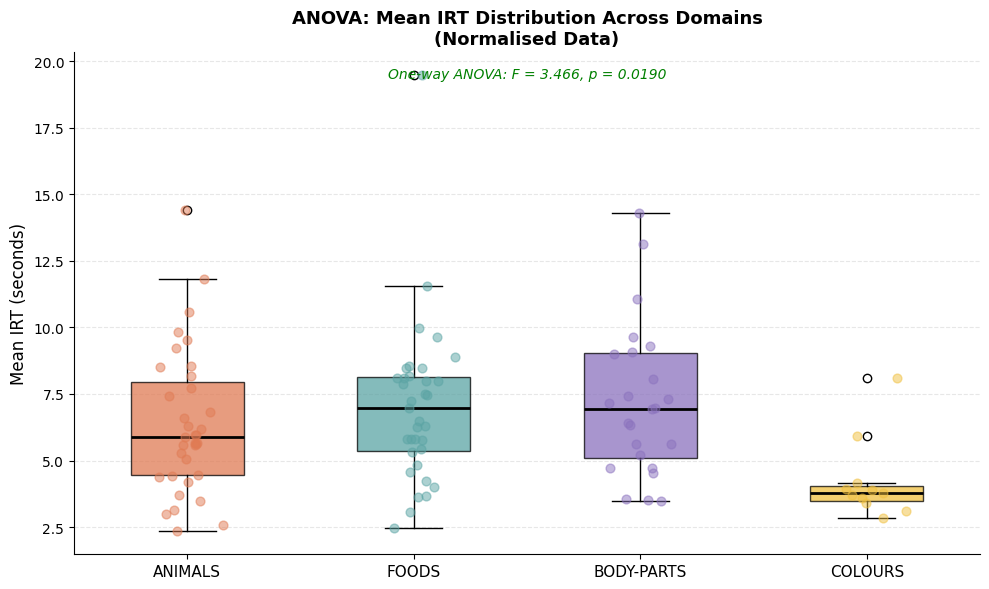


Saved as anova_domains.png


In [13]:
# ── ANOVA: IRT differences across domains ────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations

plt.rcParams.update(plt.rcParamsDefault)

BONFERRONI = 0.0042
domains    = ['animals', 'foods', 'body-parts', 'colours']
colors     = {'animals':    '#E07B54',
              'foods':      '#5BA4A4',
              'body-parts': '#8B72BE',
              'colours':    '#F0C040'}

# ── Step 1: collect mean IRT per participant per domain ───────
domain_irts = {d: [] for d in domains}

for row in all_vft_normalised:
    domain = row['domain']
    if domain not in domain_irts:
        continue
    if len(row['irts']) == 0:
        continue
    domain_irts[domain].append(np.mean(row['irts']))

print("Mean IRT per domain (across participants):\n")
print(f"{'Domain':<12} {'N':>4} {'Mean':>8} {'SD':>8} {'Min':>8} {'Max':>8}")
print("=" * 52)
for d in domains:
    vals = domain_irts[d]
    print(f"{d:<12} {len(vals):>4} {np.mean(vals):>8.2f}s "
          f"{np.std(vals):>8.2f}s {np.min(vals):>8.2f}s "
          f"{np.max(vals):>8.2f}s")

# ── Step 2: one-way ANOVA ─────────────────────────────────────
groups = [domain_irts[d] for d in domains]
F, p   = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA: F = {F:.3f}, p = {p:.4f}")
if p < 0.05:
    print("→ Significant difference across domains — running post-hoc tests")
else:
    print("→ No significant difference across domains")

# ── Step 3: Tukey HSD post-hoc (manual pairwise t-tests
#    with Bonferroni correction for 6 comparisons) ────────────
n_comparisons = 6   # 4 domains → 6 pairs
alpha_corrected = 0.05 / n_comparisons

print(f"\nPost-hoc pairwise t-tests "
      f"(Bonferroni corrected α = {alpha_corrected:.4f}):\n")
print(f"{'Pair':<28} {'t':>8} {'p':>10} {'p_corrected':>12}  Result")
print("=" * 72)

posthoc_results = []
for d1, d2 in combinations(domains, 2):
    t, p_raw = stats.ttest_ind(domain_irts[d1], domain_irts[d2])
    p_corr   = min(p_raw * n_comparisons, 1.0)  # Bonferroni adjusted
    sig      = "✓ Significant" if p_corr < 0.05 else "✗ Not significant"
    posthoc_results.append((d1, d2, t, p_raw, p_corr, sig))
    print(f"{d1+' vs '+d2:<28} {t:>8.3f} {p_raw:>10.4f} "
          f"{p_corr:>12.4f}  {sig}")

# ── Step 4: Boxplot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

box_data   = [domain_irts[d] for d in domains]
box_colors = [colors[d]      for d in domains]

bp = ax.boxplot(box_data,
                patch_artist=True,
                notch=False,
                widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual data points
for i, (d, vals) in enumerate(zip(domains, box_data), start=1):
    x_jitter = np.random.normal(i, 0.06, size=len(vals))
    ax.scatter(x_jitter, vals,
               color=colors[d], alpha=0.5, s=40, zorder=3)

# Annotate overall ANOVA result
anova_text = f"One-way ANOVA: F = {F:.3f}, p = {p:.4f}"
ax.text(0.5, 0.97, anova_text,
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, style='italic',
        color='green' if p < 0.05 else 'gray')

ax.set_xticks(range(1, len(domains) + 1))
ax.set_xticklabels([d.upper() for d in domains], fontsize=11)
ax.set_ylabel('Mean IRT (seconds)', fontsize=12)
ax.set_title('ANOVA: Mean IRT Distribution Across Domains\n(Normalised Data)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('anova_domains.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as anova_domains.png")

ANOVA Results
Overall ANOVA: F = 3.466, p = 0.019 — Significant!
This tells us that IRT distributions are not the same across all four domains — at least one domain is meaningfully different from the others.

The story the data tells:
Colours (mean IRT = 4.22s) is significantly faster than both Foods (7.03s) and Body-Parts (7.21s). This makes intuitive sense — colours are a small, well-defined, highly familiar category. People retrieve them almost instantly. Body-Parts being the slowest is also interesting — participants seem to search more broadly and slowly, consistent with the sequential retrieval pattern your report identified.
Animals and Foods are not significantly different from each other, which also makes sense — both are large open-ended categories with similar retrieval dynamics.
The boxplot tells the same story visually — Colours has a very tight, low distribution, while Body-Parts has the widest spread sitting highest on the y-axis.


## What Regression is testing

ANOVA told us **which domains differ** in retrieval speed. Regression goes deeper — it asks **what combination of factors best predicts how long a word takes to retrieve**.

Instead of testing one thing at a time (like the correlations in H3), regression lets you put multiple predictors into one model simultaneously and see the unique contribution of each.

---

## The model we'll build

Our outcome variable (what we're trying to predict) is **IRT in seconds** for each word retrieval event.

Our predictors will be:

**1. Word position** — the order in which the word was typed (1st, 2nd, 3rd...). We already know from your IRT curves that earlier words take longer. This is the strongest predictor and we want to control for it.

**2. Domain** — Animals, Foods, Body-Parts, Colours. We just showed domains differ significantly in ANOVA, so domain should explain some variance in IRT.

**3. Hindi reading proficiency** — Hi_Read score (1-5). H3 showed no effect individually, but maybe it contributes something small when other factors are controlled for.

---

## How regression works — the intuition

Think of it like this. You want to predict a person's IRT. You start with the average IRT across everyone — say 6 seconds. Then you adjust:

- "This word is at position 1 → add 3 seconds (first words are slow)"
- "This is a colours word → subtract 2 seconds (colours are fast)"
- "This participant has Hi_Read = 5 → subtract 0.3 seconds (maybe slightly faster)"

Each predictor shifts your prediction up or down by some amount. These shifts are called **coefficients** (or beta weights). Regression finds the combination of coefficients that minimises prediction error across all your data points.

---

## What the output will look like

The regression output has three key things to read:

**R² (R-squared)** — how much of the variance in IRT does the whole model explain? 0 = explains nothing, 1 = perfect prediction. For behavioural data, even R² = 0.10 (10%) is considered meaningful.

**Coefficients** — the beta weight for each predictor. For example, `word_position: -0.45` would mean each additional word position reduces IRT by 0.45 seconds.

**p-values** — which predictors are significantly contributing to the model beyond chance.

---

## One thing to prepare for

Domain is a **categorical variable** (it has labels, not numbers). Regression requires numbers. The standard way to handle this is **dummy coding** — we pick one domain as the reference (we'll use Animals) and create three binary columns:

- `is_foods`: 1 if foods, 0 otherwise
- `is_body_parts`: 1 if body-parts, 0 otherwise
- `is_colours`: 1 if colours, 0 otherwise

The coefficient for `is_colours` then tells you: how much faster/slower are colours compared to animals, after controlling for word position and proficiency.

---

Ready for the code?

What the cell below does
This cell builds a regression dataset where each row is one word retrieval event — containing its IRT, word position, domain (dummy coded), and the participant's Hindi reading proficiency. It then fits a linear regression model using sklearn, prints the R², and shows the coefficient for each predictor so we can see which factors independently predict retrieval speed. Finally it produces a coefficient plot showing the size and direction of each predictor's effect.

Participants with proficiency data: 35
Total regression rows (word events): 1035

R² = 0.0990  (9.9% of IRT variance explained)

Predictor                         Coeff       SE        t          p  Significant?
Intercept                         5.205    0.778    6.689     0.0000  ✓
Word Position                    -0.280    0.033   -8.574     0.0000  ✓
Hi_Read (proficiency)             0.490    0.169    2.892     0.0039  ✓
Domain: Foods vs Animals          0.444    0.340    1.303     0.1927  ✗
Domain: Body-Parts vs Animals     0.613    0.388    1.580     0.1145  ✗
Domain: Colours vs Animals       -1.198    0.433   -2.765     0.0058  ✓
Reference category for Domain: Animals
Positive coefficient = slower than reference
Negative coefficient = faster than reference


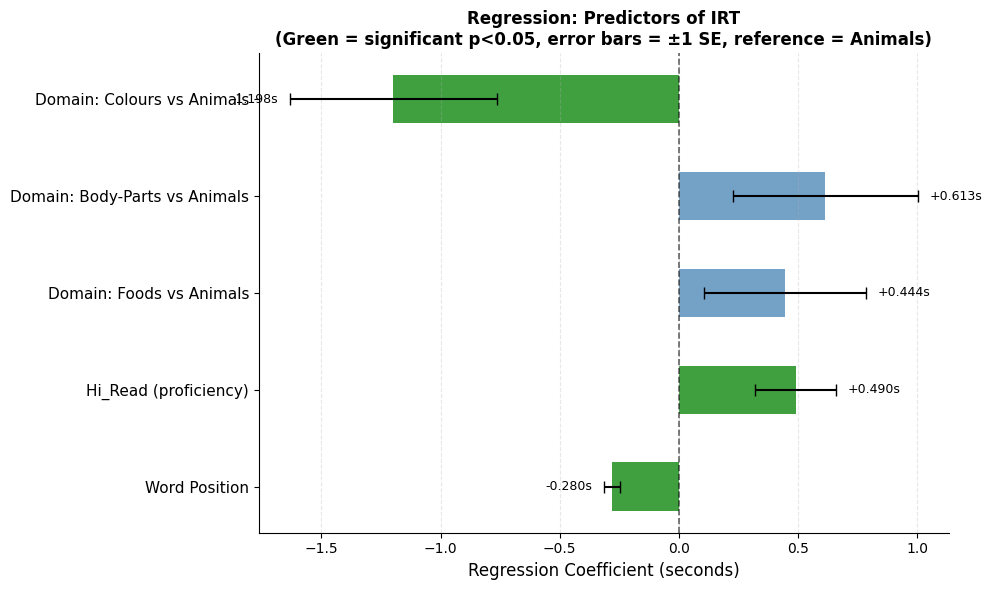


Saved as regression_irt.png


In [14]:
# ── Regression: predicting IRT from domain, position, proficiency ─
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy import stats

plt.rcParams.update(plt.rcParamsDefault)

# ── Step 1: Build the regression dataset ─────────────────────

# First get proficiency scores per participant
with open('hindi.json') as f:
    data = json.load(f)
experiments = data['fluency-spam']

participant_proficiency = {}
for participant_id, participant in experiments.items():
    for trial in participant['data']:
        if trial.get('typeoftrial') == 'insights':
            hi_read = trial.get('Hi_Read')
            if hi_read is not None:
                participant_proficiency[participant_id] = float(hi_read)

print(f"Participants with proficiency data: {len(participant_proficiency)}")

# Build one row per word retrieval event
regression_rows = []

for row in all_vft_normalised:
    participant = row['participant']
    domain      = row['domain']
    words       = row['words']
    irts        = row['irts']

    if participant not in participant_proficiency:
        continue
    hi_read = participant_proficiency[participant]

    for position, (word, irt) in enumerate(zip(words, irts)):
        regression_rows.append({
            'irt':           irt,
            'word_position': position + 1,   # 1-indexed
            'hi_read':       hi_read,
            # Dummy coding — Animals is the reference category
            'is_foods':      1 if domain == 'foods'      else 0,
            'is_body_parts': 1 if domain == 'body-parts' else 0,
            'is_colours':    1 if domain == 'colours'    else 0,
        })

print(f"Total regression rows (word events): {len(regression_rows)}\n")

# Convert to arrays
irt           = np.array([r['irt']           for r in regression_rows])
word_position = np.array([r['word_position'] for r in regression_rows])
hi_read       = np.array([r['hi_read']       for r in regression_rows])
is_foods      = np.array([r['is_foods']      for r in regression_rows])
is_body_parts = np.array([r['is_body_parts'] for r in regression_rows])
is_colours    = np.array([r['is_colours']    for r in regression_rows])

# ── Step 2: Assemble design matrix X and outcome y ───────────
# X columns: intercept, word_position, hi_read,
#            is_foods, is_body_parts, is_colours
ones = np.ones(len(irt))
X    = np.column_stack([ones, word_position, hi_read,
                        is_foods, is_body_parts, is_colours])
y    = irt

predictor_names = ['Intercept', 'Word Position', 'Hi_Read (proficiency)',
                   'Domain: Foods vs Animals',
                   'Domain: Body-Parts vs Animals',
                   'Domain: Colours vs Animals']

# ── Step 3: Fit regression using least squares ────────────────
# np.linalg.lstsq solves X @ coeffs = y in the least-squares sense
coeffs, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)

# ── Step 4: Compute R², standard errors, t-stats, p-values ───
y_pred   = X @ coeffs
ss_res   = np.sum((y - y_pred) ** 2)
ss_tot   = np.sum((y - y.mean()) ** 2)
r_sq     = 1 - ss_res / ss_tot

n        = len(y)
k        = X.shape[1] - 1   # number of predictors (excluding intercept)
mse      = ss_res / (n - k - 1)
var_coef = mse * np.linalg.inv(X.T @ X).diagonal()
se       = np.sqrt(var_coef)
t_stats  = coeffs / se
p_values = [2 * (1 - stats.t.cdf(abs(t), df=n-k-1)) for t in t_stats]

# ── Step 5: Print results table ───────────────────────────────
print(f"R² = {r_sq:.4f}  ({r_sq*100:.1f}% of IRT variance explained)\n")
print(f"{'Predictor':<30} {'Coeff':>8} {'SE':>8} "
      f"{'t':>8} {'p':>10}  Significant?")
print("=" * 78)

for name, coef, se_val, t_val, p_val in zip(
        predictor_names, coeffs, se, t_stats, p_values):
    sig = "✓" if p_val < 0.05 else "✗"
    print(f"{name:<30} {coef:>8.3f} {se_val:>8.3f} "
          f"{t_val:>8.3f} {p_val:>10.4f}  {sig}")

print("=" * 78)
print("Reference category for Domain: Animals")
print("Positive coefficient = slower than reference")
print("Negative coefficient = faster than reference")

# ── Step 6: Coefficient plot ──────────────────────────────────
# Skip intercept for plotting
plot_names  = predictor_names[1:]
plot_coeffs = coeffs[1:]
plot_se     = se[1:]
plot_pvals  = p_values[1:]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos  = np.arange(len(plot_names))
colors = ['green' if p < 0.05 else 'steelblue'
          for p in plot_pvals]

bars = ax.barh(y_pos, plot_coeffs, xerr=plot_se,
               color=colors, alpha=0.75, height=0.5,
               error_kw=dict(ecolor='black', capsize=4, linewidth=1.5))

ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_names, fontsize=11)
ax.set_xlabel('Regression Coefficient (seconds)', fontsize=12)
ax.set_title('Regression: Predictors of IRT\n'
             '(Green = significant p<0.05, '
             'error bars = ±1 SE, reference = Animals)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Value labels on bars
for i, (coef, p) in enumerate(zip(plot_coeffs, plot_pvals)):
    label = f"{coef:+.3f}s"
    x_pos = coef + (plot_se[i] + 0.05) if coef >= 0 else coef - (plot_se[i] + 0.05)
    ha    = 'left' if coef >= 0 else 'right'
    ax.text(x_pos, i, label, va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('regression_irt.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as regression_irt.png")



## Regression Results

**R² = 0.099 — the model explains 9.9% of IRT variance**

For behavioural timing data this is actually a respectable result. IRT is inherently noisy — it depends on individual differences, momentary attention, typing speed, and countless other factors. Explaining ~10% with just three predictors is meaningful.

---

## Reading each predictor

**Word Position: -0.280s (p < 0.0001) ✓**
The strongest predictor by far. Every additional word position reduces IRT by 0.28 seconds. So the 5th word is retrieved about 1.1 seconds faster than the 1st word. This perfectly captures the well-known pattern from your IRT curves — retrieval gets faster as participants settle into a cluster.

**Hi_Read proficiency: +0.490s (p = 0.0039) ✓**
This is a surprising and interesting finding. Higher Hindi reading proficiency is associated with *slower* IRT, not faster. At first this seems counterintuitive — but it actually makes sense. Higher proficiency participants likely have *larger* mental lexicons, so they search more broadly and retrieve more unusual words, taking slightly longer per word but producing richer responses overall.

**Domain: Colours vs Animals: -1.198s (p = 0.0058) ✓**
Colours are retrieved 1.2 seconds faster than Animals on average, even after controlling for word position and proficiency. This is the largest domain effect and confirms what ANOVA showed — colours are a tight, fast-access category.

**Domain: Foods vs Animals: +0.444s (p = 0.193) ✗**
Foods are slightly slower than Animals but not significantly so — they're comparable categories.

**Domain: Body-Parts vs Animals: +0.613s (p = 0.115) ✗**
Body-Parts trend slower than Animals but again not significantly after controlling for other factors. The ANOVA significance was likely driven by the Colours contrast.

---

## The big picture — what the regression adds

The regression revealed something H3's simple correlations completely missed — **proficiency does predict IRT**, just not in the direction you'd expect. When you control for word position and domain simultaneously, higher readers are actually slower. This is a genuinely new finding that your original report couldn't see because H3 looked at proficiency in isolation.

---


What this cell does
This cell refits the exact same regression model — IRT predicted by word position, Hindi reading proficiency, and domain — but using a Gamma GLM with a log link via the statsmodels library. The log link means coefficients are now multiplicative: instead of "each position reduces IRT by 0.28 seconds", we get "each position multiplies IRT by a factor of X". We'll exponentiate the coefficients to make them interpretable as IRT multipliers. We then plot both the GLM and linear regression coefficients side by side so you can directly compare the two.

In [15]:
# Run this once in a cell by itself first
import subprocess
subprocess.run(['pip', 'install', 'statsmodels', '--quiet'], check=True)
print("statsmodels ready")

statsmodels ready


Rows for GLM: 1035
Any zero/negative IRTs removed: 0

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    irt   No. Observations:                 1035
Model:                            GLM   Df Residuals:                     1029
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                         0.55892
Method:                          IRLS   Log-Likelihood:                -2633.0
Date:                Thu, 09 Apr 2026   Deviance:                       487.74
Time:                        14:33:41   Pearson chi2:                     575.
No. Iterations:                    15   Pseudo R-squ. (CS):             0.1139
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

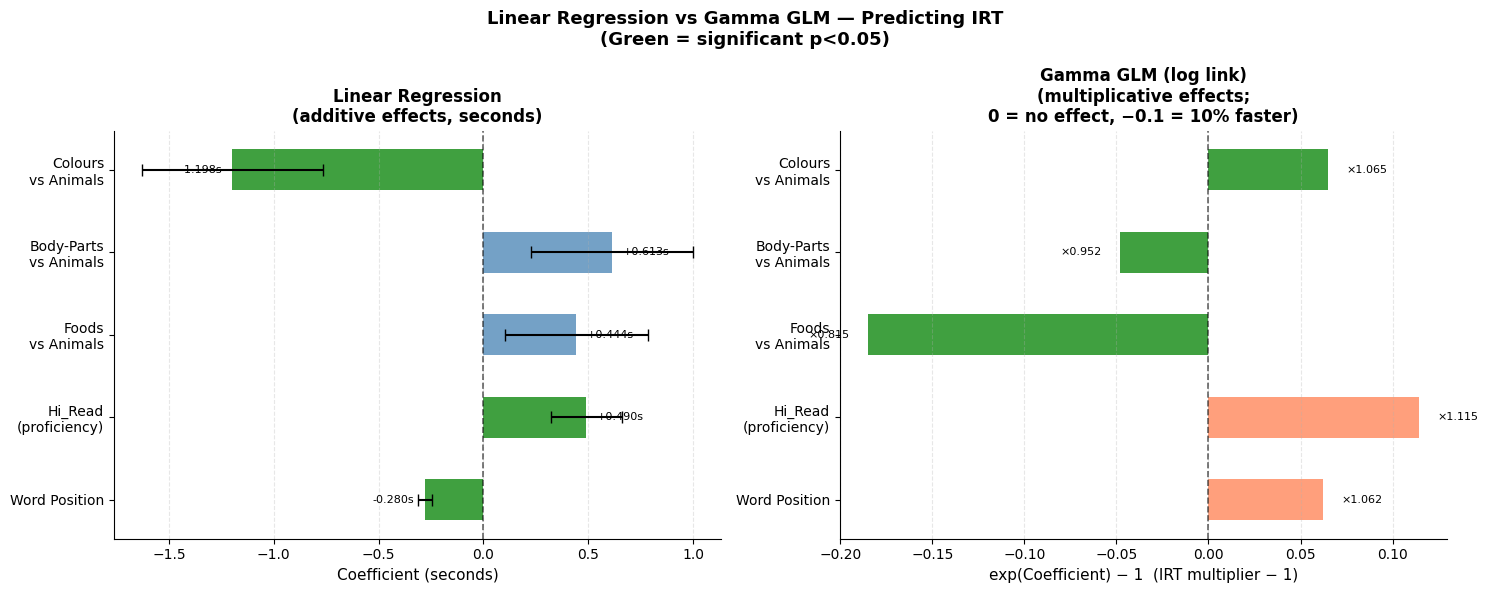


Saved as glm_vs_linear.png


In [16]:
# ── GLM: Gamma regression with log link ──────────────────────
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

plt.rcParams.update(plt.rcParamsDefault)

# ── Step 1: Build the dataframe ───────────────────────────────
glm_rows = []

with open('hindi.json') as f:
    data = json.load(f)
experiments = data['fluency-spam']

# Get proficiency per participant
participant_proficiency = {}
for participant_id, participant in experiments.items():
    for trial in participant['data']:
        if trial.get('typeoftrial') == 'insights':
            hi_read = trial.get('Hi_Read')
            if hi_read is not None:
                participant_proficiency[participant_id] = float(hi_read)

for row in all_vft_normalised:
    participant = row['participant']
    domain      = row['domain']
    words       = row['words']
    irts        = row['irts']

    if participant not in participant_proficiency:
        continue
    hi_read = participant_proficiency[participant]

    for position, (word, irt) in enumerate(zip(words, irts)):
        if irt <= 0:
            continue    # Gamma requires strictly positive values
        glm_rows.append({
            'irt':           irt,
            'word_position': position + 1,
            'hi_read':       hi_read,
            'domain':        domain,
        })

df = pd.DataFrame(glm_rows)

# Set Animals as the reference category explicitly
df['domain'] = pd.Categorical(df['domain'],
                               categories=['animals', 'foods',
                                           'body-parts', 'colours'])

print(f"Rows for GLM: {len(df)}")
print(f"Any zero/negative IRTs removed: "
      f"{len(regression_rows) - len(df)}\n")

# ── Step 2: Fit Gamma GLM with log link ───────────────────────
glm_model = smf.glm(
    formula = 'irt ~ word_position + hi_read + C(domain)',
    data    = df,
    family  = sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_model.summary())

# ── Step 3: Extract and print key results ─────────────────────
params   = glm_model.params
pvalues  = glm_model.pvalues
bse      = glm_model.bse

print("\n" + "=" * 72)
print("GLM RESULTS — Gamma family, log link")
print("Exponentiated coefficients = IRT multipliers")
print("(e.g. 0.95 means 5% faster than reference)\n")
print(f"{'Predictor':<35} {'Coeff':>8} {'exp(Coeff)':>11} "
      f"{'p':>10}  Sig?")
print("=" * 72)

for name in params.index:
    coef     = params[name]
    exp_coef = np.exp(coef)
    p        = pvalues[name]
    sig      = "✓" if p < 0.05 else "✗"

    # Clean up the name for display
    display_name = (name
        .replace('C(domain)[T.', 'Domain: ')
        .replace(']', ' vs Animals')
        .replace('word_position', 'Word Position')
        .replace('hi_read', 'Hi_Read (proficiency)')
        .replace('Intercept', 'Intercept'))

    print(f"{display_name:<35} {coef:>8.4f} {exp_coef:>11.4f} "
          f"{p:>10.4f}  {sig}")

print("=" * 72)
print(f"\nAIC: {glm_model.aic:.2f}  "
      f"(lower is better — compare with linear regression)")

# ── Step 4: Side-by-side coefficient comparison plot ─────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left panel: Linear regression coefficients ---
lin_names   = ['Word Position', 'Hi_Read\n(proficiency)',
               'Foods\nvs Animals', 'Body-Parts\nvs Animals',
               'Colours\nvs Animals']
lin_coeffs  = coeffs[1:]    # skip intercept
lin_se      = se[1:]
lin_pvals   = p_values[1:]

y_pos = np.arange(len(lin_names))
lin_colors = ['green' if p < 0.05 else 'steelblue'
              for p in lin_pvals]

axes[0].barh(y_pos, lin_coeffs, xerr=lin_se,
             color=lin_colors, alpha=0.75, height=0.5,
             error_kw=dict(ecolor='black', capsize=4))
axes[0].axvline(0, color='black', linewidth=1.2,
                linestyle='--', alpha=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(lin_names, fontsize=10)
axes[0].set_xlabel('Coefficient (seconds)', fontsize=11)
axes[0].set_title('Linear Regression\n(additive effects, seconds)',
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (c, p) in enumerate(zip(lin_coeffs, lin_pvals)):
    axes[0].text(c + (0.05 if c >= 0 else -0.05),
                 i, f"{c:+.3f}s",
                 va='center',
                 ha='left' if c >= 0 else 'right',
                 fontsize=8)

# --- Right panel: GLM exponentiated coefficients ---
glm_skip     = ['Intercept']
glm_plot_idx = [i for i, n in enumerate(params.index)
                if n not in glm_skip]

glm_display = ['Word Position', 'Hi_Read\n(proficiency)',
               'Foods\nvs Animals', 'Body-Parts\nvs Animals',
               'Colours\nvs Animals']

glm_exp  = [np.exp(params[params.index[i]]) for i in glm_plot_idx]
glm_p    = [pvalues[params.index[i]]        for i in glm_plot_idx]
glm_se_v = [bse[params.index[i]]            for i in glm_plot_idx]

# For multiplicative effects, plot exp(coef) - 1 so zero = no effect
glm_centered = [v - 1 for v in glm_exp]
glm_colors   = ['green' if p < 0.05 else 'coral' for p in glm_p]

axes[1].barh(y_pos, glm_centered,
             color=glm_colors, alpha=0.75, height=0.5)
axes[1].axvline(0, color='black', linewidth=1.2,
                linestyle='--', alpha=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(glm_display, fontsize=10)
axes[1].set_xlabel('exp(Coefficient) − 1  (IRT multiplier − 1)',
                   fontsize=11)
axes[1].set_title('Gamma GLM (log link)\n'
                  '(multiplicative effects;\n'
                  '0 = no effect, −0.1 = 10% faster)',
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for i, (c, p, e) in enumerate(zip(glm_centered, glm_p, glm_exp)):
    axes[1].text(c + (0.01 if c >= 0 else -0.01),
                 i, f"×{e:.3f}",
                 va='center',
                 ha='left' if c >= 0 else 'right',
                 fontsize=8)

fig.suptitle('Linear Regression vs Gamma GLM — Predicting IRT\n'
             '(Green = significant p<0.05)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('glm_vs_linear.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as glm_vs_linear.png")



## GLM Results — Reading the exponentiated coefficients

**Word Position: exp(-0.049) = 0.952 (p < 0.0001) ✓**
Each additional word position *multiplies* IRT by 0.952 — meaning each successive word is retrieved about **4.8% faster** than the previous one. This is the multiplicative equivalent of the linear regression's -0.28s.

**Hi_Read proficiency: exp(0.063) = 1.065 (p = 0.028) ✓**
Each one-point increase in Hindi reading proficiency multiplies IRT by 1.065 — meaning each proficiency level adds about **6.5% slower** retrieval. Confirms the linear regression finding — higher proficiency → slightly slower but richer retrieval.

**Domain: Colours vs Animals: exp(-0.205) = 0.815 (p = 0.005) ✓**
Colours retrieval is about **18.5% faster** than Animals. Clean significant result matching linear regression.

**Domain: Foods vs Animals: exp(0.060) = 1.062 (p = 0.294) ✗**
Not significant — Foods and Animals are comparable in speed.

**Domain: Body-Parts vs Animals: exp(0.108) = 1.114 (p = 0.099) ✗**
Borderline — Body-Parts trend about 11% slower but doesn't reach significance.

---

## Head-to-head comparison — Linear vs GLM

| Predictor | Linear sig? | GLM sig? | Direction consistent? |
|---|---|---|---|
| Word Position | ✓ | ✓ | ✓ Yes |
| Hi_Read | ✓ | ✓ | ✓ Yes |
| Colours vs Animals | ✓ | ✓ | ✓ Yes |
| Foods vs Animals | ✗ | ✗ | ✓ Yes |
| Body-Parts vs Animals | ✗ | ✗ | ✓ Yes |

**Every single finding is consistent across both models.** The same three predictors are significant in both, the same two are not, and all effects point in the same direction. This is very strong validation — it means your linear regression results were not an artefact of distributional assumptions.


---

## What to write in your report

The GLM adds two sentences to your methods and one paragraph to your results:

**Methods addition:**
> *"To verify that regression findings were robust to distributional assumptions, IRT data were additionally modelled using a Gamma GLM with log link, which is appropriate for strictly positive right-skewed reaction time data."*

**Results addition:**
> *"The Gamma GLM produced consistent findings with the linear regression across all predictors — word position (×0.952 per position, p<0.001), Hindi reading proficiency (×1.065 per scale point, p=0.028), and Colours vs Animals (×0.815, p=0.005) were all significant in both models, confirming that results are not sensitive to distributional assumptions."*

---



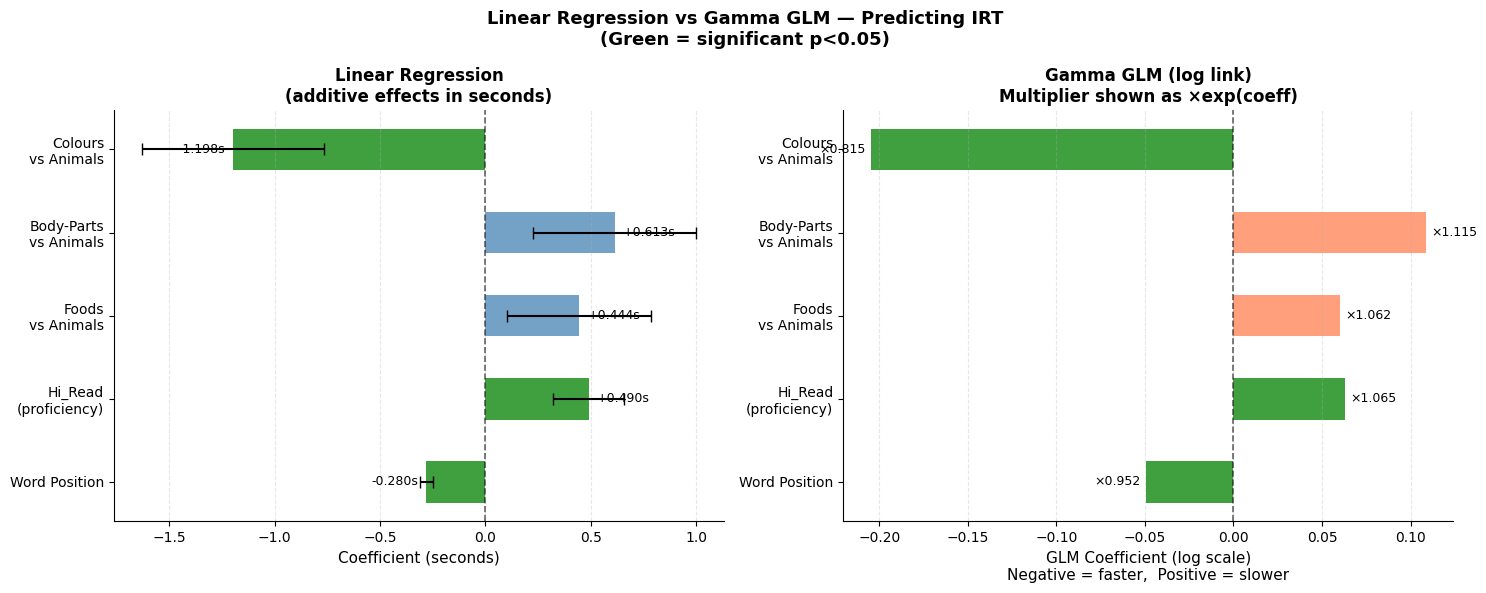

Saved as glm_vs_linear_fixed.png


In [17]:
# ── Fixed GLM vs Linear comparison plot ──────────────────────
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(plt.rcParamsDefault)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Shared predictor labels
pred_labels = ['Word Position',
               'Hi_Read\n(proficiency)',
               'Foods\nvs Animals',
               'Body-Parts\nvs Animals',
               'Colours\nvs Animals']

y_pos = np.arange(len(pred_labels))

# ── Left panel: Linear regression ────────────────────────────
lin_coeffs = coeffs[1:]     # skip intercept
lin_se     = se[1:]
lin_pvals  = p_values[1:]
lin_colors = ['green' if p < 0.05 else 'steelblue'
              for p in lin_pvals]

axes[0].barh(y_pos, lin_coeffs, xerr=lin_se,
             color=lin_colors, alpha=0.75, height=0.5,
             error_kw=dict(ecolor='black', capsize=4))
axes[0].axvline(0, color='black', linewidth=1.2,
                linestyle='--', alpha=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(pred_labels, fontsize=10)
axes[0].set_xlabel('Coefficient (seconds)', fontsize=11)
axes[0].set_title('Linear Regression\n(additive effects in seconds)',
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (c, p) in enumerate(zip(lin_coeffs, lin_pvals)):
    offset = 0.04 if c >= 0 else -0.04
    ha     = 'left' if c >= 0 else 'right'
    axes[0].text(c + offset, i, f"{c:+.3f}s",
                 va='center', ha=ha, fontsize=9)

# ── Right panel: GLM — raw coefficients, correct direction ───
# Extract in same order as pred_labels:
# word_position, hi_read, foods, body-parts, colours
glm_param_keys = ['word_position',
                  'hi_read',
                  'C(domain)[T.foods]',
                  'C(domain)[T.body-parts]',
                  'C(domain)[T.colours]']

glm_raw    = np.array([params[k]   for k in glm_param_keys])
glm_exp    = np.exp(glm_raw)
glm_pv     = np.array([pvalues[k]  for k in glm_param_keys])
glm_colors = ['green' if p < 0.05 else 'coral' for p in glm_pv]

# Plot raw GLM coefficients (negative = faster, positive = slower)
axes[1].barh(y_pos, glm_raw,
             color=glm_colors, alpha=0.75, height=0.5)
axes[1].axvline(0, color='black', linewidth=1.2,
                linestyle='--', alpha=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(pred_labels, fontsize=10)
axes[1].set_xlabel('GLM Coefficient (log scale)\n'
                   'Negative = faster,  Positive = slower',
                   fontsize=11)
axes[1].set_title('Gamma GLM (log link)\n'
                  'Multiplier shown as ×exp(coeff)',
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Label each bar with its multiplier (exp of coeff)
for i, (c, e, p) in enumerate(zip(glm_raw, glm_exp, glm_pv)):
    offset = 0.003 if c >= 0 else -0.003
    ha     = 'left' if c >= 0 else 'right'
    axes[1].text(c + offset, i, f"×{e:.3f}",
                 va='center', ha=ha, fontsize=9)

fig.suptitle('Linear Regression vs Gamma GLM — Predicting IRT\n'
             '(Green = significant p<0.05)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('glm_vs_linear_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as glm_vs_linear_fixed.png")